In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

In [2]:
# =========================================================
# 0) Helpers & Styling
# =========================================================
# Налаштування єдиної світлої теми для всіх графіків
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "white", 
    "axes.facecolor": "white",
    "text.color": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})

def clean_name(x: str) -> str:
    return (
        str(x)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
        .replace("/", "_")
    )

def safe_text(s: pd.Series) -> pd.Series:
    return s.fillna("missing").astype(str).str.strip().replace("", "missing")

def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    return df

def optimize_threshold(y_true, y_proba):
    best = {"threshold": 0.5, "f1": -1, "precision": 0, "recall": 0}
    for t in np.linspace(0.05, 0.95, 91):
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": float(f1),
                "precision": float(precision_score(y_true, y_pred, zero_division=0)),
                "recall": float(recall_score(y_true, y_pred, zero_division=0))
            })
    return best

# Завантаження даних (заміни шляхи на свої, якщо потрібно)
df_train_transactions = pd.read_csv('data/train_transactions.csv')
df_train_user = pd.read_csv('data/train_users.csv')

In [3]:
# =========================================================
# 1) Prepare raw data & Time Split
# =========================================================
users = df_train_user.copy()
tx = df_train_transactions.copy()

users["timestamp_reg"] = pd.to_datetime(users["timestamp_reg"], utc=True, errors="coerce")
tx["timestamp_tr"] = pd.to_datetime(tx["timestamp_tr"], utc=True, errors="coerce")
users, tx = users.dropna(subset=["timestamp_reg"]).copy(), tx.dropna(subset=["timestamp_tr"]).copy()

users["gender"] = safe_text(users["gender"])
users["reg_country"] = safe_text(users["reg_country"])
users["traffic_type"] = safe_text(users["traffic_type"])
users["is_fraud"] = users["is_fraud"].astype(int)

# Time split by users (80/20)
users_sorted = users.sort_values("timestamp_reg").reset_index(drop=True)
cutoff_idx = int(len(users_sorted) * 0.8)
cutoff_time = users_sorted.loc[cutoff_idx, "timestamp_reg"]

train_users = users_sorted[users_sorted["timestamp_reg"] < cutoff_time].copy()
val_users = users_sorted[users_sorted["timestamp_reg"] >= cutoff_time].copy()

train_user_ids, val_user_ids = set(train_users["id_user"]), set(val_users["id_user"])

train_tx = tx[(tx["id_user"].isin(train_user_ids)) & (tx["timestamp_tr"] < cutoff_time)].copy()
val_tx = tx[(tx["id_user"].isin(val_user_ids)) & (tx["timestamp_tr"] >= cutoff_time)].copy()

print(f"Cutoff: {cutoff_time} | Train users: {train_users.shape[0]} | Val users: {val_users.shape[0]}")

Cutoff: 2025-07-02 13:49:19.020453+00:00 | Train users: 146212 | Val users: 36554


In [4]:
# =========================================================
# 2) Feature builder (Clean & Specific Rates)
# =========================================================
def build_features(users_part: pd.DataFrame, tx_part: pd.DataFrame) -> pd.DataFrame:
    # Базові колонки юзера (БЕЗ email фіч)
    base_cols = ["id_user", "traffic_type", "gender", "reg_country"]
    if "is_fraud" in users_part.columns:
        base_cols.append("is_fraud")
        
    base = users_part[base_cols].copy()

    if tx_part.empty:
        return base

    txp = tx_part.copy()
    
    # Базова підготовка
    txp["amount"] = pd.to_numeric(txp["amount"], errors="coerce").fillna(0).astype("float32")
    txp["status"] = safe_text(txp["status"])
    txp["transaction_type"] = safe_text(txp["transaction_type"])
    txp["error_group"] = safe_text(txp["error_group"])
    txp["is_success"] = (txp["status"] == "success").astype(int)
    txp["is_failed"] = (txp["status"] == "failed").astype(int)

    # Час та гео-невідповідність
    txp = txp.merge(users_part[["id_user", "timestamp_reg", "reg_country"]], on="id_user", how="left")
    txp["hours_from_reg"] = ((txp["timestamp_tr"] - txp["timestamp_reg"]).dt.total_seconds() / 3600.0).fillna(0).astype("float32")
    txp["is_24h"] = (txp["hours_from_reg"] <= 24.0).astype(int)
    
    txp["reg_card_country_mismatch"] = (txp["reg_country"].fillna("missing") != txp["card_country"].fillna("missing")).astype(int)
    txp["reg_payment_country_mismatch"] = (txp["reg_country"].fillna("missing") != txp["payment_country"].fillna("missing")).astype(int)
    txp["card_payment_country_mismatch"] = (txp["card_country"].fillna("missing") != txp["payment_country"].fillna("missing")).astype(int)

    # Віконні функції (проміжки часу)
    txp = txp.sort_values(["id_user", "timestamp_tr"])
    txp["prev_tx_time"] = txp.groupby("id_user")["timestamp_tr"].shift(1)
    txp["gap_hours"] = ((txp["timestamp_tr"] - txp["prev_tx_time"]).dt.total_seconds() / 3600.0).fillna(0).astype("float32")
    txp["tx_date"] = txp["timestamp_tr"].dt.floor("D")

    # Нормалізація холдера (БЕЗ n_unique_card_holders_norm)
    txp["card_holder_norm"] = txp["card_holder"].fillna("").astype(str).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    txp["card_holder_len"] = txp["card_holder_norm"].str.len().fillna(0).astype("float32")
    txp["card_holder_word_count"] = txp["card_holder_norm"].str.split().str.len().fillna(0).astype("float32")
    txp["card_holder_long"] = (txp["card_holder_len"] >= 20).astype(int)

    # Підготовка типів транзакцій та конкретних помилок
    known_tx_types = ["card_init", "card_recurring", "google-pay", "apple-pay", "resign"]
    for t in known_tx_types:
        txp[f"tx_type_{clean_name(t)}"] = (txp["transaction_type"] == t).astype(int)

    # Виділяємо лише ті помилки, про які ти просив
    txp["err_cvv"] = (txp["error_group"] == "cvv error").astype(int)
    txp["err_insufficient_funds"] = (txp["error_group"] == "insufficient funds error").astype(int)

    # Card graph (юзерів на картку)
    users_per_card = txp.groupby("card_mask_hash")["id_user"].nunique().reset_index().rename(columns={"id_user": "n_users_per_card"})
    txp = txp.merge(users_per_card, on="card_mask_hash", how="left")

    # ---------- Єдиний великий AGG блок ----------
    aggs = txp.groupby("id_user").agg(
        n_tx=("timestamp_tr", "size"),
        n_success=("is_success", "sum"),
        n_failed=("is_failed", "sum"),
        amount_sum=("amount", "sum"),
        amount_mean=("amount", "mean"),
        amount_std=("amount", "std"),
        
        n_unique_transaction_types=("transaction_type", "nunique"),
        n_unique_currencies=("currency", "nunique"),
        n_unique_card_brands=("card_brand", "nunique"),
        n_unique_card_types=("card_type", "nunique"),
        n_unique_card_countries=("card_country", "nunique"),
        n_unique_payment_countries=("payment_country", "nunique"),
        n_unique_card_holders=("card_holder", "nunique"),
        n_unique_cards=("card_mask_hash", "nunique"),
        
        # Гео-невідповідності
        reg_card_country_mismatch_rate=("reg_card_country_mismatch", "mean"),
        reg_payment_country_mismatch_rate=("reg_payment_country_mismatch", "mean"),
        card_payment_country_mismatch_rate=("card_payment_country_mismatch", "mean"),
        avg_hours_from_reg=("hours_from_reg", "mean"),
        cards_24h=("is_24h", lambda x: txp.loc[x.index, "card_mask_hash"].nunique()),
        
        # Card Graph
        max_users_per_card=("n_users_per_card", "max"),
        mean_users_per_card=("n_users_per_card", "mean"),
        median_users_per_card=("n_users_per_card", "median"),
        cards_with_shared_use=("n_users_per_card", lambda s: (s >= 2).sum()),
        
        # Holder
        card_holder_len_mean=("card_holder_len", "mean"),
        card_holder_len_std=("card_holder_len", "std"),
        card_holder_word_count_mean=("card_holder_word_count", "mean"),
        card_holder_long_rate=("card_holder_long", "mean"),
        
        # Time
        n_active_days=("tx_date", "nunique"),
        tx_span_hours=("timestamp_tr", lambda s: ((s.max() - s.min()).total_seconds() / 3600.0) if len(s) > 1 else 0.0),
        mean_gap_hours=("gap_hours", "mean"),
        min_gap_hours=("gap_hours", "min"),
        std_gap_hours=("gap_hours", "std"),
        
        # Суми помилок для подальшого розрахунку rate
        err_cvv_sum=("err_cvv", "sum"),
        err_insufficient_funds_sum=("err_insufficient_funds", "sum"),
    )

    # Додаємо суми типів транзакцій
    for t in known_tx_types:
        aggs[f"tx_type_{clean_name(t)}"] = txp.groupby("id_user")[f"tx_type_{clean_name(t)}"].sum()

    aggs = aggs.reset_index()

    # ---------- Похідні метрики (Rates) ----------
    aggs["success_rate"] = aggs["n_success"] / aggs["n_tx"].replace(0, np.nan)
    aggs["failed_rate"] = aggs["n_failed"] / aggs["n_tx"].replace(0, np.nan)
    aggs["amount_per_tx"] = aggs["amount_sum"] / aggs["n_tx"].replace(0, np.nan)
    aggs["amount_cv"] = aggs["amount_std"] / (aggs["amount_mean"].abs() + 1e-6)
    aggs["failed_to_success_ratio"] = aggs["n_failed"] / (aggs["n_success"] + 1.0)
    aggs["card_user_score"] = aggs["n_unique_cards"] * aggs["max_users_per_card"]
    
    # Кастомні rate-фічі по помилках
    aggs["err_cvv_rate"] = aggs["err_cvv_sum"] / aggs["n_tx"].replace(0, np.nan)
    aggs["err_insufficient_funds_rate"] = aggs["err_insufficient_funds_sum"] / aggs["n_tx"].replace(0, np.nan)
    
    # Видаляємо тимчасові суми, залишаємо тільки rate (якщо суми тобі не потрібні)
    aggs = aggs.drop(columns=["err_cvv_sum", "err_insufficient_funds_sum"])

    # Збираємо все разом
    out = base.merge(aggs, on="id_user", how="left")
    
    num_cols = out.select_dtypes(include=["number"]).columns
    out[num_cols] = out[num_cols].fillna(0)
    
    # Виправляємо нулі для card graph (мінімум 1 юзер на картку)
    out["max_users_per_card"] = out["max_users_per_card"].replace(0, 1)
    out["mean_users_per_card"] = out["mean_users_per_card"].replace(0, 1)
    out["median_users_per_card"] = out["median_users_per_card"].replace(0, 1)

    return reduce_memory(out)

In [5]:
# =========================================================
# 3) Train & Eval
# =========================================================
train_df = build_features(train_users, train_tx)
val_df = build_features(val_users, val_tx)

X_train = train_df.drop(columns=["id_user", "is_fraud"])
y_train = train_df["is_fraud"]
X_val = val_df.drop(columns=["id_user", "is_fraud"])
y_val = val_df["is_fraud"]

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Використовуємо AUC, щоб модель не зупинялася зарано
model = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    eval_metric="AUC", auto_class_weights="Balanced", 
    random_seed=42, verbose=100, od_type="Iter", od_wait=40
)

model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_val, y_val), use_best_model=True)

y_proba = model.predict_proba(X_val)[:, 1]
best = optimize_threshold(y_val, y_proba)

print("\n=== ВАЛІДАЦІЯ МОДЕЛІ ===")
print(f"Best Threshold: {best['threshold']:.2f}")
print(f"F1: {best['f1']:.4f} | Precision: {best['precision']:.4f} | Recall: {best['recall']:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")

0:	test: 0.9236136	best: 0.9236136 (0)	total: 111ms	remaining: 33.1s
100:	test: 0.9503818	best: 0.9503818 (100)	total: 4.98s	remaining: 9.81s
200:	test: 0.9538359	best: 0.9538359 (200)	total: 12.1s	remaining: 5.97s
299:	test: 0.9563766	best: 0.9563766 (299)	total: 17s	remaining: 0us

bestTest = 0.956376566
bestIteration = 299


=== ВАЛІДАЦІЯ МОДЕЛІ ===
Best Threshold: 0.89
F1: 0.5605 | Precision: 0.5391 | Recall: 0.5837
ROC-AUC: 0.9564


In [6]:
# =========================================================
# 4) Симуляція Гібридного Підходу
# =========================================================
def simulate_hybrid_approach(y_true, y_prob, t_yellow=0.75, t_red=0.96):
    decisions = np.where(y_prob >= t_red, 'Red (Auto-Block)', 
                         np.where(y_prob >= t_yellow, 'Yellow (Manual Review)', 'Green (Auto-Approve)'))
    
    df_sim = pd.DataFrame({'truth': y_true, 'prob': y_prob, 'decision': decisions})
    
    summary = df_sim.groupby('decision').agg(
        Users=('truth', 'count'),
        Actual_Fraud=('truth', 'sum')
    ).reset_index()
    
    summary['Traffic_Pct'] = summary['Users'] / len(df_sim) * 100
    summary['Fraud_Rate'] = summary['Actual_Fraud'] / summary['Users'] * 100
    
    print(f"\n=== СИМУЛЯЦІЯ ГІБРИДНОГО ПІДХОДУ (Thresholds: {t_yellow} / {t_red}) ===")
    print(summary.to_string(index=False))
    
    return df_sim, summary

df_sim, summary_df = simulate_hybrid_approach(y_val, y_proba, t_yellow=0.75, t_red=0.96)


=== СИМУЛЯЦІЯ ГІБРИДНОГО ПІДХОДУ (Thresholds: 0.75 / 0.96) ===
              decision  Users  Actual_Fraud  Traffic_Pct  Fraud_Rate
  Green (Auto-Approve)  33212           315    90.857362    0.948452
      Red (Auto-Block)    647           472     1.769984   72.952087
Yellow (Manual Review)   2695           712     7.372654   26.419295


/tmp/ipykernel_2073/1559953132.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feat_imp, palette="Blues_r")


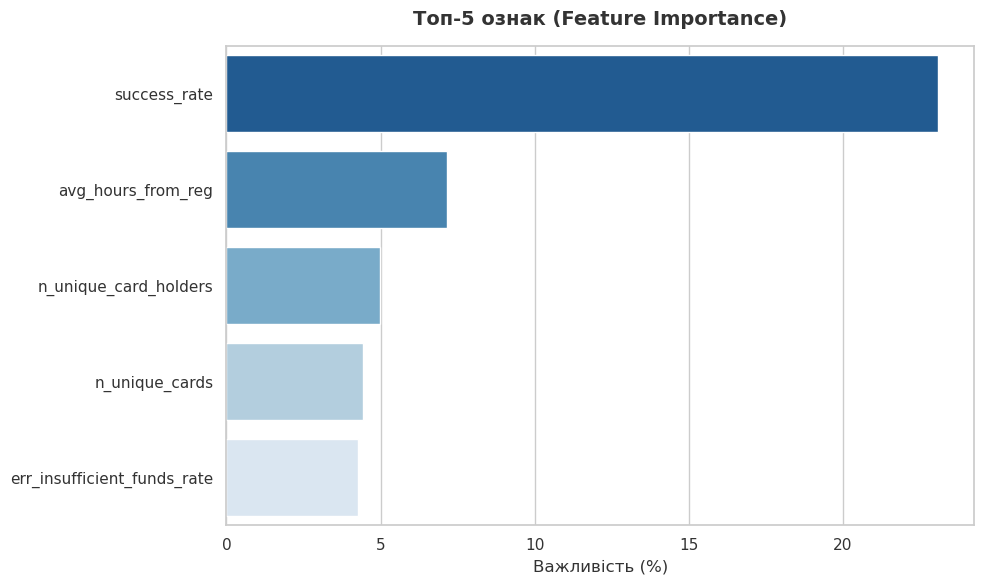

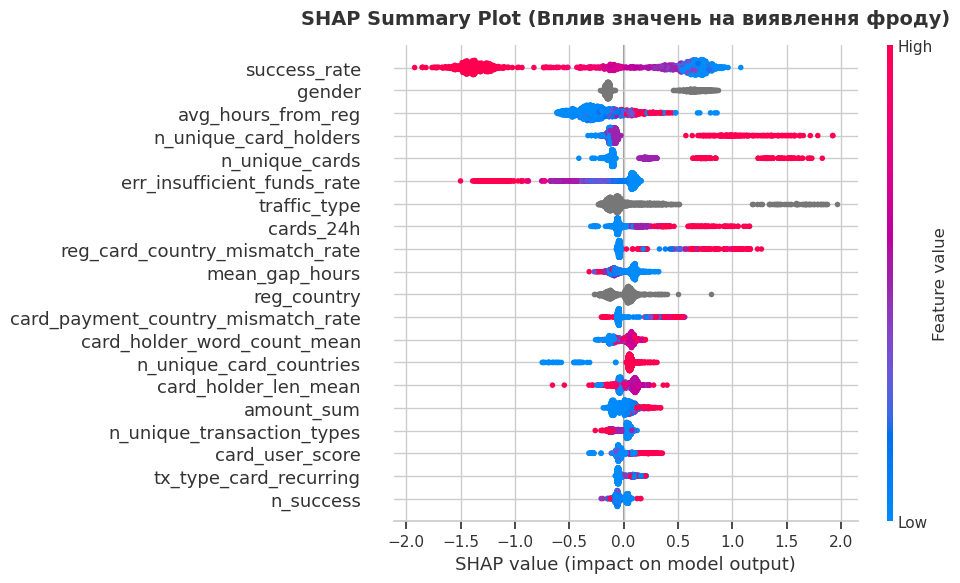

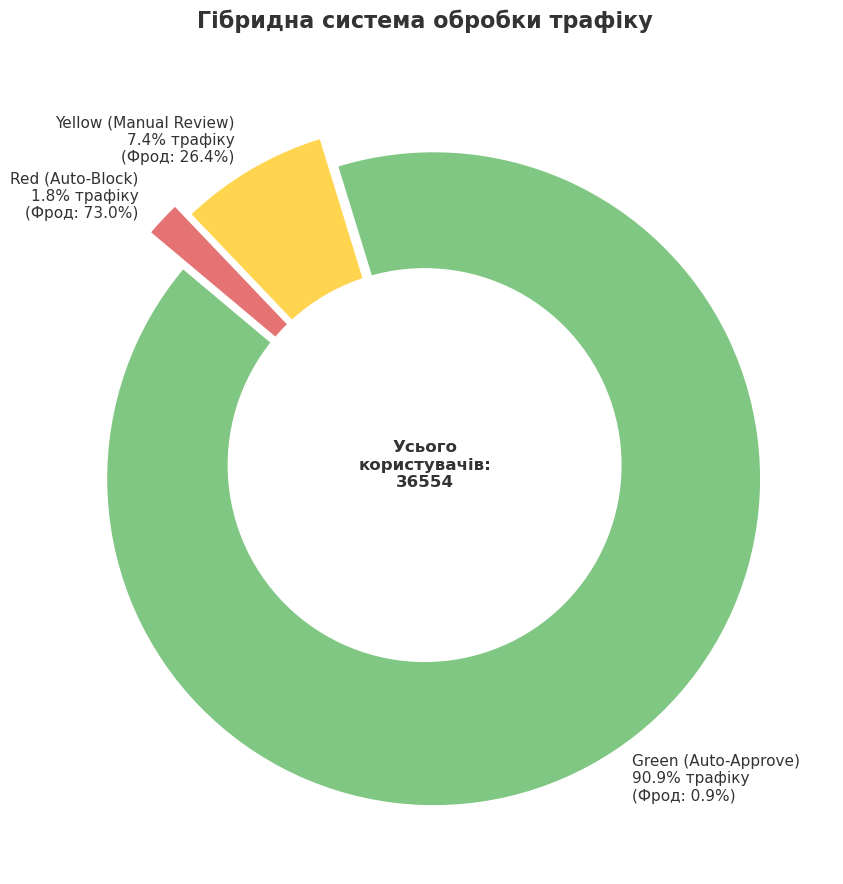

In [7]:
# =========================================================
# 5) Візуалізації (Світла тема)
# =========================================================

# 5.1 Графік Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False).head(5) # <--- ЗМІНЕНО ТУТ: виводимо лише топ 5

sns.barplot(x="importance", y="feature", data=feat_imp, palette="Blues_r")
plt.title("Топ-5 ознак (Feature Importance)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Важливість (%)", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

# 5.2 Графік SHAP
plt.figure(figsize=(10, 6))
X_sample = X_val.sample(n=min(1500, len(X_val)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

plt.title("SHAP Summary Plot (Вплив значень на виявлення фроду)", fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(shap_values, X_sample, show=False, plot_size=None)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

# 5.3 Кругова діаграма зон ризику (Pie Chart)
def plot_zones_pie_chart(summary_df):
    # Кольори для зон (м'які/світлі)
    color_map = {
        'Green (Auto-Approve)': '#81C784',   # М'який зелений
        'Yellow (Manual Review)': '#FFD54F', # М'який жовтий
        'Red (Auto-Block)': '#E57373'        # М'який червоний
    }
    
    # Сортуємо, щоб кольори і зони йшли в логічному порядку
    summary_df['Sort'] = summary_df['decision'].map({'Green (Auto-Approve)': 0, 'Yellow (Manual Review)': 1, 'Red (Auto-Block)': 2})
    summary_df = summary_df.sort_values('Sort')
    
    labels = []
    for _, row in summary_df.iterrows():
        # Формуємо підпис: Назва зони + % трафіку + % фроду всередині
        label = f"{row['decision']}\n{row['Traffic_Pct']:.1f}% трафіку\n(Фрод: {row['Fraud_Rate']:.1f}%)"
        labels.append(label)
        
    sizes = summary_df['Users']
    colors = [color_map[d] for d in summary_df['decision']]
    
    # Налаштування графіка
    fig, ax = plt.subplots(figsize=(9, 9))
    wedges, texts, autotexts = ax.pie(
        sizes, 
        colors=colors,
        labels=labels, 
        autopct='', # Ми вже вказали % трафіку в лейблах, тому тут пусте
        startangle=140,
        pctdistance=0.85,
        explode=(0.05, 0.05, 0.1), # Трохи віддаляємо червону зону для акценту
        shadow=False,
        textprops={'fontsize': 11, 'color': '#333333', 'fontweight': '500'}
    )
    
    # Біле коло по центру (робимо Donut chart для естетики)
    centre_circle = plt.Circle((0,0), 0.60, fc='white')
    fig.gca().add_artist(centre_circle)
    
    plt.title("Гібридна система обробки трафіку", fontsize=16, fontweight='bold', pad=20)
    
    # Додаємо текст по центру
    total_users = summary_df['Users'].sum()
    plt.text(0, 0, f"Усього\nкористувачів:\n{total_users}", ha='center', va='center', fontsize=12, fontweight='bold', color='#333333')
    
    plt.tight_layout()
    plt.savefig("hybrid_zones_pie_chart.png", dpi=300)
    plt.show()

plot_zones_pie_chart(summary_df)